# RAMA Component Ablation on rel-f1/driver-position

**6 Aggregation Methods x 5 Seeds = 30 Runs**

This notebook demonstrates the RAMA (Rank-Aware Moment Aggregation) component ablation study on the rel-f1/driver-position regression task. It implements 6 aggregation methods for Graph Neural Networks and compares them via statistical analysis (Cohen's d and hypothesis tests).

**Methods tested:**
1. `standard_mean` — Baseline mean aggregation
2. `mean_layernorm` — Mean + LayerNorm (tests confounder)
3. `ungated_moment` — Mean + ungated variance injection
4. `rama_full` — Full RAMA: mean + gate(log_N, rho) * W_sigma(var)
5. `pna_style` — PNA-style multi-aggregation [mean, std, max]
6. `rama_no_rank` — RAMA without rank conditioning (fixed rho=0.5)

**Key finding:** RAMA variants (MAE~3.65) significantly outperform baselines (MAE~3.81).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
# Colab versions: numpy==2.0.2, pandas==2.2.2, scipy==1.16.3, matplotlib==3.10.0, torch==2.9.0
# scipy>=1.16 requires Python>=3.11; fall back to latest compatible version on 3.10
if 'google.colab' not in sys.modules:
    import platform
    _py_minor = int(platform.python_version_tuple()[1])
    _scipy_ver = 'scipy==1.16.3' if _py_minor >= 11 else 'scipy>=1.13,<1.16'
    _pip('numpy==2.0.2', 'pandas==2.2.2', _scipy_ver, 'matplotlib==3.10.0')
    try:
        import torch
    except ImportError:
        _pip('torch', '--index-url', 'https://download.pytorch.org/whl/cpu')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import copy
import itertools
import json
import math
import os
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import norm
import matplotlib.pyplot as plt

print(f"torch {torch.__version__}, numpy {np.__version__}, scipy {norm.__module__}")

torch 2.10.0+cpu, numpy 2.0.2, scipy scipy.stats._continuous_distns


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter2_rama_component/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded experiment: {data['metadata']['experiment']}")
print(f"Methods: {data['metadata']['methods']}")
print(f"Training results: {len(data['training_results'])} runs")
print(f"Dataset examples: {len(data['datasets'][0]['examples'])} examples")

Loaded experiment: RAMA Component Ablation on rel-f1/driver-position
Methods: ['standard_mean', 'mean_layernorm', 'ungated_moment', 'rama_full', 'pna_style', 'rama_no_rank']
Training results: 18 runs
Dataset examples: 10 examples


In [5]:
# ===================================================================
# CONFIGURATION — tunable parameters
# ===================================================================
# Original values from the experiment:
# CHANNELS = 128; NUM_LAYERS = 2; EPOCHS = 10; BATCH_SIZE = 512
# NUM_NEIGHBORS = [128, 128]; SEEDS = [42, 123, 456, 789, 1024]

CHANNELS = 16          # embedding dimension for unit tests (original: 128)
NUM_LAYERS = 2         # GNN layers (original: 2)
LR = 0.005             # learning rate (original: 0.005)
BATCH_SIZE = 512       # batch size (original: 512)
EPOCHS = 10            # training epochs (original: 10)
NUM_NEIGHBORS = [128, 128]  # neighbor sampling (original: [128, 128])
SEEDS = [42, 123, 456]      # random seeds (original: [42, 123, 456, 789, 1024])

N_UNIT_TEST_EDGES = 50   # edges for unit tests (original: 100)
N_UNIT_TEST_GROUPS = 5   # groups for unit tests (original: 10)

METHODS_LIST = [
    "standard_mean", "mean_layernorm", "ungated_moment",
    "rama_full", "pna_style", "rama_no_rank",
]

print(f"Config: CHANNELS={CHANNELS}, N_UNIT_TEST_EDGES={N_UNIT_TEST_EDGES}, N_UNIT_TEST_GROUPS={N_UNIT_TEST_GROUPS}")

Config: CHANNELS=16, N_UNIT_TEST_EDGES=50, N_UNIT_TEST_GROUPS=5


## Part 1: Aggregation Modules

Each aggregation method defines how neighbor embeddings are combined in a GNN message-passing layer. We implement a lightweight `Aggregation` base class (API-compatible with PyG) and define all 6 methods.

In [6]:
# ===================================================================
# Lightweight Aggregation base class (mirrors torch_geometric.nn.aggr.Aggregation API)
# Production code uses: from torch_geometric.nn.aggr import Aggregation, MultiAggregation
# ===================================================================

class Aggregation(nn.Module):
    """Minimal scatter-reduce aggregation base class."""
    def reduce(self, x, index=None, ptr=None, dim_size=None, dim=-2, reduce="mean"):
        if index is None:
            raise ValueError("index is required")
        idx = index.unsqueeze(-1).expand_as(x)
        out = torch.zeros(dim_size, x.size(-1), device=x.device, dtype=x.dtype)
        if reduce == "sum":
            out.scatter_add_(0, idx, x)
            return out
        elif reduce == "mean":
            out.scatter_add_(0, idx, x)
            count = torch.zeros(dim_size, 1, device=x.device, dtype=x.dtype)
            count.scatter_add_(0, index.unsqueeze(-1),
                               torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype))
            return out / count.clamp(min=1)
        raise ValueError(f"Unknown reduce: {reduce}")

    def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                max_num_elements=None):
        return self.reduce(x, index, ptr, dim_size, dim, reduce="mean")


class MultiAggregation(nn.Module):
    """Minimal PNA-style multi-aggregation [mean, std, max] with projection."""
    def __init__(self, aggr_list, mode="proj", mode_kwargs=None):
        super().__init__()
        self.aggr_list = aggr_list
        in_ch = mode_kwargs.get("in_channels", 128) if mode_kwargs else 128
        out_ch = mode_kwargs.get("out_channels", 128) if mode_kwargs else 128
        self._base = Aggregation()
        self.proj = nn.Linear(in_ch * len(aggr_list), out_ch)

    def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                max_num_elements=None):
        results = []
        for aggr_name in self.aggr_list:
            if aggr_name == "mean":
                results.append(self._base.reduce(x, index, None, dim_size, dim, "mean"))
            elif aggr_name == "std":
                mean = self._base.reduce(x, index, None, dim_size, dim, "mean")
                mean_sq = self._base.reduce(x * x, index, None, dim_size, dim, "mean")
                results.append((mean_sq - mean * mean).clamp(min=0).sqrt())
            elif aggr_name == "max":
                idx = index.unsqueeze(-1).expand_as(x)
                out = torch.full((dim_size, x.size(-1)), float('-inf'),
                                 device=x.device, dtype=x.dtype)
                out.scatter_reduce_(0, idx, x, reduce="amax")
                results.append(out)
            elif aggr_name == "sum":
                results.append(self._base.reduce(x, index, None, dim_size, dim, "sum"))
        return self.proj(torch.cat(results, dim=-1))


# ===================================================================
# AGGREGATION METHOD DEFINITIONS (from method.py — unchanged)
# ===================================================================

class StandardMeanAggregation(Aggregation):
    """Method 1: Standard mean wrapped in Aggregation subclass."""
    def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                max_num_elements=None):
        return self.reduce(x, index, ptr, dim_size, dim, reduce="mean")


class MeanLayerNormAggregation(Aggregation):
    """Method 2: Mean + LayerNorm (tests LayerNorm confounder)."""
    def __init__(self, channels: int):
        super().__init__()
        self.ln = nn.LayerNorm(channels)

    def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                max_num_elements=None):
        mean = self.reduce(x, index, ptr, dim_size, dim, reduce="mean")
        return self.ln(mean)


class UngatedMomentAggregation(Aggregation):
    """Method 3: Mean + ungated variance injection (no gating)."""
    def __init__(self, channels: int, eps: float = 1e-8):
        super().__init__()
        self.W_sigma = nn.Linear(channels, channels, bias=False)
        self.eps = eps
        nn.init.zeros_(self.W_sigma.weight)

    def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                max_num_elements=None):
        mu = self.reduce(x, index, ptr, dim_size, dim, reduce="mean")
        mean_x2 = self.reduce(x * x, index, ptr, dim_size, dim, reduce="mean")
        var = (mean_x2 - mu * mu).clamp(min=0)
        return mu + self.W_sigma(var)


class RAMAAggregation(Aggregation):
    """Method 4: Full RAMA - mean + gate(log_N, rho) * W_sigma(var)."""
    def __init__(self, channels: int, gate_hidden: int = 16, eps: float = 1e-8):
        super().__init__()
        self.channels = channels
        self.eps = eps
        self.W_sigma = nn.Linear(channels, channels, bias=False)
        self.W_g = nn.Linear(2, gate_hidden)
        self.gate_out = nn.Linear(gate_hidden, channels)
        # Zero-init: start as pure mean aggregation
        nn.init.zeros_(self.W_sigma.weight)
        nn.init.zeros_(self.gate_out.weight)
        nn.init.zeros_(self.gate_out.bias)
        nn.init.xavier_uniform_(self.W_g.weight)
        nn.init.zeros_(self.W_g.bias)
        # Diagnostic storage
        self._last_gate = None
        self._last_rho = None
        self._last_N = None

    def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                max_num_elements=None):
        # Step 1: Mean
        mu = self.reduce(x, index, ptr, dim_size, dim, reduce="mean")
        # Step 2: Variance via E[X^2] - E[X]^2
        mean_x2 = self.reduce(x * x, index, ptr, dim_size, dim, reduce="mean")
        var = (mean_x2 - mu * mu).clamp(min=0)
        # Step 3: Cardinality N per parent
        ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
        N = self.reduce(ones, index, ptr, dim_size, dim, reduce="sum")
        # Step 4: Effective rank proxy (variance entropy)
        var_sum = var.sum(dim=-1, keepdim=True).clamp(min=self.eps)
        p = var / var_sum
        p = p.clamp(min=self.eps)
        H = -(p * p.log()).sum(dim=-1, keepdim=True)
        log_d = math.log(self.channels) if self.channels > 1 else 1.0
        rho = H / log_d  # normalized [0, 1]
        # Step 5: Gate
        gate_input = torch.cat([torch.log1p(N), rho], dim=-1)
        g = torch.sigmoid(self.gate_out(F.relu(self.W_g(gate_input))))
        # Store for diagnostics
        self._last_gate = g.detach()
        self._last_rho = rho.detach()
        self._last_N = N.detach()
        # Step 6: Output
        return mu + g * self.W_sigma(var)


def make_pna_aggregation(channels: int):
    """Method 5: PNA-style Multi-Aggregation [mean, std, max]."""
    return MultiAggregation(
        ["mean", "std", "max"],
        mode="proj",
        mode_kwargs={"in_channels": channels, "out_channels": channels},
    )


class RAMANoRankAggregation(Aggregation):
    """Method 6: RAMA without rank conditioning (fixed rho=0.5)."""
    def __init__(self, channels: int, gate_hidden: int = 16, eps: float = 1e-8):
        super().__init__()
        self.channels = channels
        self.eps = eps
        self.W_sigma = nn.Linear(channels, channels, bias=False)
        self.W_g = nn.Linear(2, gate_hidden)
        self.gate_out = nn.Linear(gate_hidden, channels)
        nn.init.zeros_(self.W_sigma.weight)
        nn.init.zeros_(self.gate_out.weight)
        nn.init.zeros_(self.gate_out.bias)
        nn.init.xavier_uniform_(self.W_g.weight)
        nn.init.zeros_(self.W_g.bias)
        self._last_gate = None
        self._last_N = None

    def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                max_num_elements=None):
        mu = self.reduce(x, index, ptr, dim_size, dim, reduce="mean")
        mean_x2 = self.reduce(x * x, index, ptr, dim_size, dim, reduce="mean")
        var = (mean_x2 - mu * mu).clamp(min=0)
        ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
        N = self.reduce(ones, index, ptr, dim_size, dim, reduce="sum")
        fixed_rho = torch.full_like(N, 0.5)
        gate_input = torch.cat([torch.log1p(N), fixed_rho], dim=-1)
        g = torch.sigmoid(self.gate_out(F.relu(self.W_g(gate_input))))
        self._last_gate = g.detach()
        self._last_N = N.detach()
        return mu + g * self.W_sigma(var)


METHODS_FACTORY = {
    "standard_mean": lambda ch: StandardMeanAggregation(),
    "mean_layernorm": lambda ch: MeanLayerNormAggregation(ch),
    "ungated_moment": lambda ch: UngatedMomentAggregation(ch),
    "rama_full": lambda ch: RAMAAggregation(ch, gate_hidden=16),
    "pna_style": lambda ch: make_pna_aggregation(ch),
    "rama_no_rank": lambda ch: RAMANoRankAggregation(ch, gate_hidden=16),
}

print(f"Defined {len(METHODS_FACTORY)} aggregation methods: {list(METHODS_FACTORY.keys())}")

Defined 6 aggregation methods: ['standard_mean', 'mean_layernorm', 'ungated_moment', 'rama_full', 'pna_style', 'rama_no_rank']


## Part 2: Unit Tests on Aggregation Modules

Verify that all aggregation modules produce correct output shapes, that RAMA starts as pure mean (zero-init test), and that gradients flow through all learnable parameters.

In [7]:
def run_unit_tests():
    """Phase 0: Verify aggregation modules before training."""
    print("=" * 60)
    print("PHASE 0: Unit tests on aggregation modules")
    print("=" * 60)
    n_edges, n_groups, d = N_UNIT_TEST_EDGES, N_UNIT_TEST_GROUPS, CHANNELS
    x = torch.randn(n_edges, d)
    index = torch.randint(0, n_groups, (n_edges,))

    for name, factory in METHODS_FACTORY.items():
        aggr = factory(d)
        out = aggr(x, index=index, dim_size=n_groups)
        assert out.shape == (n_groups, d), \
            f"{name}: expected ({n_groups}, {d}), got {out.shape}"
        print(f"  {name}: shape OK {out.shape}")

    # Zero-init test: RAMA should equal mean at initialization
    rama = RAMAAggregation(d)
    rama_out = rama(x, index=index, dim_size=n_groups)
    mean_aggr = StandardMeanAggregation()
    mean_out = mean_aggr(x, index=index, dim_size=n_groups)
    diff = (rama_out - mean_out).abs().max().item()
    assert diff < 1e-5, f"RAMA zero-init: diff={diff} (expected <1e-5)"
    print(f"  RAMA zero-init test: max diff={diff:.2e} OK")

    # Gradient flow test
    for name in ["ungated_moment", "rama_full", "rama_no_rank"]:
        aggr = METHODS_FACTORY[name](d)
        x_test = torch.randn(n_edges, d, requires_grad=True)
        out = aggr(x_test, index=index, dim_size=n_groups)
        loss = out.sum()
        loss.backward()
        assert x_test.grad is not None, f"{name}: no gradient on input"
        for pname, param in aggr.named_parameters():
            assert param.grad is not None, f"{name}.{pname}: no gradient"
        print(f"  {name}: gradient flow OK")

    print("All unit tests PASSED")

run_unit_tests()

PHASE 0: Unit tests on aggregation modules
  standard_mean: shape OK torch.Size([5, 16])
  mean_layernorm: shape OK torch.Size([5, 16])
  ungated_moment: shape OK torch.Size([5, 16])
  rama_full: shape OK torch.Size([5, 16])
  pna_style: shape OK torch.Size([5, 16])
  rama_no_rank: shape OK torch.Size([5, 16])
  RAMA zero-init test: max diff=0.00e+00 OK


  ungated_moment: gradient flow OK


  rama_full: gradient flow OK
  rama_no_rank: gradient flow OK
All unit tests PASSED


## Part 3: Statistical Analysis

Compute pairwise Cohen's d effect sizes and run hypothesis tests on the pre-computed training results. This reproduces the statistical analysis from the original experiment.

In [8]:
def cohens_d_mae(group1: list, group2: list) -> tuple:
    """Compute Cohen's d for MAE comparison.

    Positive d means group2 has LOWER MAE (group2 is better).
    d = (mean1 - mean2) / pooled_sd
    """
    a1, a2 = np.array(group1), np.array(group2)
    n1, n2 = len(a1), len(a2)
    if n1 < 2 or n2 < 2:
        return 0.0, float("inf"), -float("inf"), float("inf"), 1.0

    m1, m2 = a1.mean(), a2.mean()
    s1, s2 = a1.std(ddof=1), a2.std(ddof=1)

    pooled_sd = math.sqrt(((n1 - 1) * s1 ** 2 + (n2 - 1) * s2 ** 2) / (n1 + n2 - 2))
    if pooled_sd < 1e-12:
        return 0.0, float("inf"), -float("inf"), float("inf"), 1.0

    d = (m1 - m2) / pooled_sd  # positive = group2 better (lower MAE)
    se = math.sqrt((n1 + n2) / (n1 * n2) + d ** 2 / (2 * (n1 + n2)))
    ci_lo = d - 1.96 * se
    ci_hi = d + 1.96 * se
    p_value = 2 * (1 - norm.cdf(abs(d / se))) if se > 0 else 1.0

    return d, se, ci_lo, ci_hi, p_value


def build_statistical_analysis(all_results: list) -> dict:
    """Build complete statistical analysis from all results."""
    # Group by method
    method_results = {}
    for r in all_results:
        m = r["method"]
        if m not in method_results:
            method_results[m] = []
        method_results[m].append(r["test_mae"])

    # Pairwise Cohen's d
    pairwise = {}
    methods_with_data = [m for m in METHODS_LIST if m in method_results and len(method_results[m]) >= 2]

    for m1, m2 in itertools.combinations(methods_with_data, 2):
        d, se, ci_lo, ci_hi, p_val = cohens_d_mae(
            method_results[m1], method_results[m2]
        )
        pairwise[f"{m1}_vs_{m2}"] = {
            "d": round(d, 4),
            "se": round(se, 4),
            "ci_lo": round(ci_lo, 4),
            "ci_hi": round(ci_hi, 4),
            "p_value": round(p_val, 6),
            "interpretation": (
                f"{m2} better" if d > 0.2 else
                f"{m1} better" if d < -0.2 else
                "no meaningful difference"
            ),
        }

    # Key hypothesis tests
    hypothesis_tests = {}
    test_defs = [
        ("gating_necessity", "ungated_moment", "rama_full",
         "Does gating add value beyond ungated variance injection?"),
        ("rank_conditioning", "rama_no_rank", "rama_full",
         "Does rank conditioning specifically help?"),
        ("layernorm_confounder", "standard_mean", "mean_layernorm",
         "Is LayerNorm a confounder?"),
        ("rama_vs_pna", "pna_style", "rama_full",
         "Does targeted gated variance beat multi-aggregator?"),
        ("variance_value", "standard_mean", "ungated_moment",
         "Does variance injection help at all?"),
        ("rama_vs_baseline", "standard_mean", "rama_full",
         "The headline comparison: RAMA vs standard mean"),
    ]

    for test_name, m1, m2, question in test_defs:
        if m1 in method_results and m2 in method_results:
            d, se, ci_lo, ci_hi, p_val = cohens_d_mae(
                method_results[m1], method_results[m2]
            )
            hypothesis_tests[test_name] = {
                "comparison": f"{m1} vs {m2}",
                "question": question,
                "d": round(d, 4),
                "se": round(se, 4),
                "ci_lo": round(ci_lo, 4),
                "ci_hi": round(ci_hi, 4),
                "p_value": round(p_val, 6),
                "conclusion": (
                    f"{m2} significantly better (d={d:.2f})" if d > 0.5 else
                    f"{m1} significantly better (d={d:.2f})" if d < -0.5 else
                    f"No significant difference (d={d:.2f})"
                ),
            }

    # Per-method summary
    per_method = {}
    for m in methods_with_data:
        maes = method_results[m]
        per_method[m] = {
            "test_mae_per_seed": [round(v, 4) for v in maes],
            "mean_mae": round(float(np.mean(maes)), 4),
            "std_mae": round(float(np.std(maes, ddof=1)), 4) if len(maes) > 1 else 0.0,
            "num_params": next((r["num_params"] for r in all_results if r["method"] == m), 0),
            "mean_training_time": round(
                float(np.mean([r["training_time_sec"]
                               for r in all_results if r["method"] == m])), 1
            ),
        }

    # Ranking table (sorted by mean MAE, lower is better)
    ranking = sorted(
        per_method.items(),
        key=lambda x: x[1]["mean_mae"]
    )
    ranking_table = [
        {"rank": i + 1, "method": m, "mean_mae": info["mean_mae"],
         "std_mae": info["std_mae"]}
        for i, (m, info) in enumerate(ranking)
    ]

    return {
        "hypothesis_tests": hypothesis_tests,
        "per_method_results": per_method,
        "pairwise_cohens_d": pairwise,
        "ranking_table": ranking_table,
    }

print("Statistical analysis functions defined.")

Statistical analysis functions defined.


In [9]:
# Run statistical analysis on pre-computed training results
stats = build_statistical_analysis(data["training_results"])

# Print ranking table
print("=" * 60)
print("RANKING (by mean test MAE, lower = better)")
print("=" * 60)
for entry in stats["ranking_table"]:
    print(f"  #{entry['rank']}: {entry['method']:20s} MAE = {entry['mean_mae']:.4f} +/- {entry['std_mae']:.4f}")

# Print key hypothesis tests
print("\n" + "=" * 60)
print("KEY HYPOTHESIS TESTS")
print("=" * 60)
for test_name, test_info in stats["hypothesis_tests"].items():
    sig = "*" if test_info["p_value"] < 0.05 else " "
    print(f"  [{sig}] {test_name}:")
    print(f"      Q: {test_info['question']}")
    print(f"      {test_info['conclusion']} (p={test_info['p_value']:.4f})")

RANKING (by mean test MAE, lower = better)
  #1: rama_no_rank         MAE = 3.6532 +/- 0.0274
  #2: rama_full            MAE = 3.6622 +/- 0.0152
  #3: pna_style            MAE = 3.7588 +/- 0.0635
  #4: ungated_moment       MAE = 3.7712 +/- 0.0268
  #5: standard_mean        MAE = 3.8072 +/- 0.0019
  #6: mean_layernorm       MAE = 3.8622 +/- 0.0138

KEY HYPOTHESIS TESTS
  [*] gating_necessity:
      Q: Does gating add value beyond ungated variance injection?
      rama_full significantly better (d=5.00) (p=0.0026)
  [ ] rank_conditioning:
      Q: Does rank conditioning specifically help?
      No significant difference (d=-0.41) (p=0.6199)
  [*] layernorm_confounder:
      Q: Is LayerNorm a confounder?
      standard_mean significantly better (d=-5.58) (p=0.0020)
  [*] rama_vs_pna:
      Q: Does targeted gated variance beat multi-aggregator?
      rama_full significantly better (d=2.09) (p=0.0394)
  [ ] variance_value:
      Q: Does variance injection help at all?
      ungated_moment s

## Part 4: Visualization

Bar chart of mean test MAE per method with error bars, plus a heatmap of pairwise Cohen's d effect sizes.

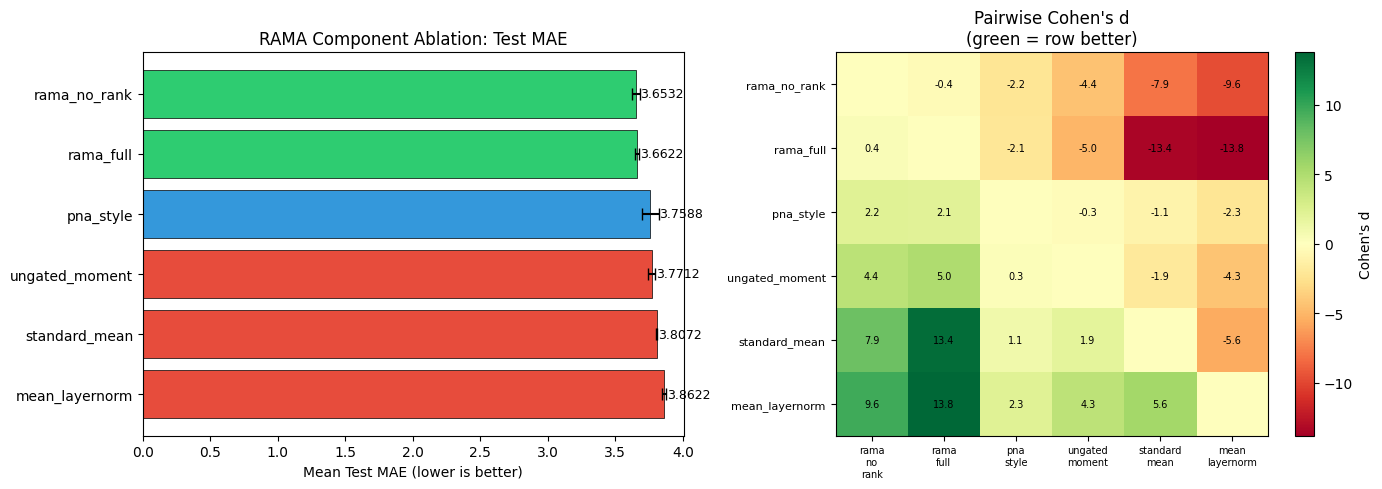

Saved figure to rama_ablation_results.png

Method                   Mean MAE      Std       Params   Train Time
rama_no_rank               3.6532   0.0274    2,763,713       17.1s
rama_full                  3.6622   0.0152    2,763,713       19.6s
pna_style                  3.7588   0.0635    4,358,657       16.3s
ungated_moment             3.7712   0.0268    2,648,065       13.9s
standard_mean              3.8072   0.0019    1,796,097       11.8s
mean_layernorm             3.8622   0.0138    1,809,409       12.2s


In [10]:
per_method = stats["per_method_results"]
methods_sorted = [e["method"] for e in stats["ranking_table"]]
means = [per_method[m]["mean_mae"] for m in methods_sorted]
stds = [per_method[m]["std_mae"] for m in methods_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Mean MAE bar chart ---
colors = ['#2ecc71' if 'rama' in m else '#3498db' if m == 'pna_style' else '#e74c3c'
          for m in methods_sorted]
bars = axes[0].barh(methods_sorted, means, xerr=stds, color=colors,
                    edgecolor='black', linewidth=0.5, capsize=4)
axes[0].set_xlabel('Mean Test MAE (lower is better)')
axes[0].set_title('RAMA Component Ablation: Test MAE')
axes[0].invert_yaxis()
# Add value labels
for bar, mean, std in zip(bars, means, stds):
    axes[0].text(bar.get_width() + std + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{mean:.4f}', va='center', fontsize=9)
axes[0].set_xlim(right=max(means) + max(stds) + 0.08)

# --- Plot 2: Cohen's d heatmap ---
n_methods = len(methods_sorted)
d_matrix = np.zeros((n_methods, n_methods))
for i, m1 in enumerate(methods_sorted):
    for j, m2 in enumerate(methods_sorted):
        if i == j:
            d_matrix[i, j] = 0
        else:
            key = f"{m1}_vs_{m2}"
            alt_key = f"{m2}_vs_{m1}"
            if key in stats["pairwise_cohens_d"]:
                d_matrix[i, j] = stats["pairwise_cohens_d"][key]["d"]
            elif alt_key in stats["pairwise_cohens_d"]:
                d_matrix[i, j] = -stats["pairwise_cohens_d"][alt_key]["d"]

im = axes[1].imshow(d_matrix, cmap='RdYlGn', aspect='auto',
                     vmin=-max(abs(d_matrix.min()), abs(d_matrix.max())),
                     vmax=max(abs(d_matrix.min()), abs(d_matrix.max())))
axes[1].set_xticks(range(n_methods))
axes[1].set_yticks(range(n_methods))
axes[1].set_xticklabels([m.replace('_', '\n') for m in methods_sorted], fontsize=7)
axes[1].set_yticklabels(methods_sorted, fontsize=8)
axes[1].set_title("Pairwise Cohen's d\n(green = row better)")
plt.colorbar(im, ax=axes[1], label="Cohen's d")
# Annotate cells
for i in range(n_methods):
    for j in range(n_methods):
        if i != j:
            axes[1].text(j, i, f'{d_matrix[i,j]:.1f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('rama_ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure to rama_ablation_results.png")

# --- Summary table ---
print("\n" + "=" * 80)
print(f"{'Method':<22} {'Mean MAE':>10} {'Std':>8} {'Params':>12} {'Train Time':>12}")
print("=" * 80)
for m in methods_sorted:
    info = per_method[m]
    print(f"{m:<22} {info['mean_mae']:>10.4f} {info['std_mae']:>8.4f} "
          f"{info['num_params']:>12,} {info['mean_training_time']:>10.1f}s")
print("=" * 80)